# Names
* Salma ALKHALILY
* Nagham ABUWARDA
* Ran LU
* Ali Alhaj

# Scientific Article Information Retrieval Challenge

This notebook guides you through the challenge step by step:

1. **Section 1 — Setup & Data Exploration**: install packages, load data, understand its structure and statistics.
2. **Section 2 — Helper Functions**: reusable utilities for data loading, chunk extraction, metrics, and evaluation.
3. **Section 3 — TF-IDF Baseline**: sparse retrieval over title + abstract.
4. **Section 4 — Dense Retrieval Baseline**: retrieval using pre-computed dense embeddings.

---

## Task Description

Given a **query** (a scientific paper), retrieve the most relevant documents from a shared **corpus** of 20,000 papers.  
Relevance is defined by **citation**: the gold documents are papers that the query paper cites.

**Submission format**: a JSON file `{query_id: [doc_id_1, ..., doc_id_100]}` — exactly 100 ranked document IDs per query.

**Evaluation**: Recall@10, Recall@100, Precision@10, MRR@10, NDCG@10, NDCG@100, MAP — computed on 100 public queries.

## Environment Setup

Run the following commands **once** from the `ir_challenge/` root folder to create a virtual environment and install all dependencies:

```bash
# Create the virtual environment with Python 3.10
python3.10 -m venv .venv

# Activate it
source .venv/bin/activate          # macOS / Linux
# .venv\Scripts\activate           # Windows

# Install dependencies
pip install -r requirements.txt
```

### Registering the kernel in Jupyter (if not detected automatically)

If Jupyter does not show the environment as a kernel option, run these two extra commands while the venv is activated:

```bash
pip install ipykernel
python -m ipykernel install --user --name ir_challenge --display-name "IR Challenge"
```

Then restart Jupyter and select **IR Challenge** from the kernel menu (`Kernel → Change Kernel`).

---

### VS Code: kernel disappears after trusting the workspace

This is a known VS Code bug — trusting the workspace triggers a re-scan that can drop `.venv` from the kernel list. Try the fixes below in order:

**Fix 1 — Register the kernel explicitly (most reliable)**

Run the two `ipykernel` commands above. This registers it as a Jupyter kernel (not just a Python environment), so it persists across trust changes. Look for it under **Select Another Kernel → Jupyter Kernel...** instead of *Python Environments*.

**Fix 2 — Set the interpreter path manually**

1. Open Command Palette (`Cmd+Shift+P` / `Ctrl+Shift+P`)
2. Type `Python: Select Interpreter`
3. Choose **Enter interpreter path...**
4. Paste: `.venv/bin/python`

Then select the kernel in the notebook — it should now stick.

**Fix 3 — Add interpreter path to VS Code workspace settings**

Open Command Palette → **Preferences: Open Workspace Settings (JSON)** and add:

```json
{
    "python.defaultInterpreterPath": "${workspaceFolder}/.venv/bin/python"
}
```

---
## Folder Structure

```
ir_challenge/
├── data/
│   ├── queries.parquet          # 100 public queries (the papers you retrieve for)
│   ├── corpus.parquet           # 20,000 candidate documents to search over
│   ├── qrels.json               # ground-truth relevance: {query_id: [doc_id, ...]}
│   ├── sample_submission.json   # example of the required submission format
│   └── embeddings/
│       └── sentence-transformers_all-MiniLM-L6-v2/   # pre-computed embeddings
│           ├── query_embeddings.npy   # shape (100, 384)
│           ├── corpus_embeddings.npy  # shape (20000, 384)
│           ├── query_ids.json         # ordered list of query doc_ids
│           ├── corpus_ids.json        # ordered list of corpus doc_ids
│           └── model_info.txt         # model name, dim, normalisation flag
├── notebooks/
│   └── challenge.ipynb          # this notebook
├── scripts/
│   └── embed.py                 # helper to re-encode with any sentence-transformers model
├── submissions/                 # created automatically when you save results
└── requirements.txt
```

### Data files

| File | Rows | Key columns |
|------|------|-------------|
| `queries.parquet` | 100 | `doc_id`, `title`, `abstract`, `ta`, `full_text`, `chunk_meta`, `domain`, `year`, `n_relevant` |
| `corpus.parquet`  | 20,000 | same columns minus `n_relevant` |
| `qrels.json` | 100 queries | `{query_id: [gold_doc_id, ...]}` — a query may have multiple relevant documents |

`n_relevant` tells you how many gold documents for that query are present in the corpus.

### Pre-computed embeddings

The embeddings were produced by [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) encoding `title + " " + abstract` for every paper. They are **L2-normalised**, so cosine similarity reduces to a dot product.

### `scripts/embed.py` — re-encoding with a different model

If you want to experiment with a stronger encoder, run this from the `ir_challenge/` folder:

```bash
python scripts/embed.py --model BAAI/bge-small-en-v1.5
```

The script automatically creates a model-named subdirectory under `data/embeddings/` so different models never overwrite each other:

```
data/embeddings/
├── sentence-transformers_all-MiniLM-L6-v2/   ← pre-computed (shipped)
└── BAAI_bge-small-en-v1.5/                   ← your new model
```

To use a custom output path explicitly:

```bash
python scripts/embed.py --model BAAI/bge-small-en-v1.5 --output data/embeddings/my_model/
```

Full options: `python scripts/embed.py --help`

---
## Section 1 — Setup & Data Exploration

In [2]:
import json
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# Paths — adjust if your layout differs
DATA_DIR = Path("../data")

# Verify files exist
for f in ["queries.parquet", "corpus.parquet", "qrels.json", "sample_submission.json"]:
    path = DATA_DIR / f
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status}  {path}")

  ✓  ..\data\queries.parquet
  ✓  ..\data\corpus.parquet
  ✓  ..\data\qrels.json
  ✓  ..\data\sample_submission.json


In [3]:
# ════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS — run this block before any retrieval
# ════════════════════════════════════════════════════════════

import json, math, os
from pathlib import Path
import numpy as np
import pandas as pd

# ── Data loaders ────────────────────────────────────────────

def load_queries(path) -> pd.DataFrame:
    """Load queries.parquet → DataFrame with doc_id, title, abstract, ta, full_text, chunk_meta, domain, year, n_relevant."""
    return pd.read_parquet(path)


def load_corpus(path) -> pd.DataFrame:
    """Load corpus.parquet → DataFrame with doc_id, title, abstract, ta, full_text, chunk_meta, domain, year."""
    return pd.read_parquet(path)


def load_qrels(path) -> dict:
    """Load qrels.json → {query_id: [doc_id, ...]}"""
    with open(path) as f:
        return json.load(f)


def load_embeddings(emb_path, ids_path):
    """
    Load pre-computed embeddings and their corresponding IDs.
    Returns (embeddings: np.ndarray float32, ids: list).
    """
    embeddings = np.load(emb_path).astype(np.float32)
    with open(ids_path) as f:
        ids = json.load(f)
    assert len(embeddings) == len(ids), "Embedding count mismatch"
    return embeddings, ids


# ── Text formatting ──────────────────────────────────────────

def format_text(row) -> str:
    """Return title + abstract as a single string for retrieval."""
    title    = str(row.get("title", "") or "").strip()
    abstract = str(row.get("abstract", "") or "").strip()
    if title and abstract:
        return title + " " + abstract
    return title or abstract


# ── Chunk extraction ─────────────────────────────────────────

def get_chunks(full_text: str, chunk_meta_json) -> list:
    """
    Extract all text sections from a paper using pre-computed chunk metadata.

    Each chunk entry has char_start and (for body chunks) the end is inferred
    as the start of the next section, or the end of full_text for the last one.

    Args:
        full_text:       raw paper text (paragraphs separated by \\n\\n)
        chunk_meta_json: JSON string or list of chunk entries from chunk_meta

    Returns:
        list of dicts: [{"type": "ta"|"body", "text": str,
                         "char_start": int, "char_end": int}]
    """
    meta = json.loads(chunk_meta_json) if isinstance(chunk_meta_json, str) else chunk_meta_json
    chunks = []
    for i, entry in enumerate(meta):
        char_start = entry["char_start"]
        if entry["type"] == "ta":
            char_end = entry["char_end"]
        else:
            # Body section spans from char_start to the next section's start (or end of text)
            char_end = meta[i + 1]["char_start"] if i + 1 < len(meta) else len(full_text)
        text = full_text[char_start:char_end].strip()
        chunks.append({"type": entry["type"], "text": text,
                       "char_start": char_start, "char_end": char_end})
    return chunks


def get_ta(row) -> str:
    """Return the pre-extracted title+abstract string from a paper row."""
    return str(row.get("ta", "") or "").strip()


def get_body_chunks(row, min_chars: int = 100) -> list:
    """
    Return all body section texts for a paper row, filtering out very short sections.

    Args:
        row:       a DataFrame row with full_text and chunk_meta columns
        min_chars: minimum character length to keep a section (default 100)
    """
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    return [c["text"] for c in chunks
            if c["type"] == "body" and len(c["text"]) >= min_chars]


# ── Metric functions (per-query) ─────────────────────────────

def recall_at_k(ranked: list, relevant: set, k: int) -> float:
    """Fraction of relevant docs found in the top-k results."""
    if not relevant:
        return 0.0
    hits = sum(1 for doc in ranked[:k] if doc in relevant)
    return hits / len(relevant)


def precision_at_k(ranked: list, relevant: set, k: int) -> float:
    """Fraction of top-k results that are relevant."""
    if k == 0:
        return 0.0
    hits = sum(1 for doc in ranked[:k] if doc in relevant)
    return hits / k


def mrr_at_k(ranked: list, relevant: set, k: int) -> float:
    """Reciprocal rank of the first relevant document in top-k."""
    for rank, doc in enumerate(ranked[:k], start=1):
        if doc in relevant:
            return 1.0 / rank
    return 0.0


def ndcg_at_k(ranked: list, relevant: set, k: int) -> float:
    """Normalized Discounted Cumulative Gain at k."""
    dcg = sum(
        1.0 / math.log2(rank + 1)
        for rank, doc in enumerate(ranked[:k], start=1)
        if doc in relevant
    )
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def average_precision(ranked: list, relevant: set) -> float:
    """Average Precision (area under the precision-recall curve) for one query."""
    if not relevant:
        return 0.0
    hits, score = 0, 0.0
    for rank, doc in enumerate(ranked, start=1):
        if doc in relevant:
            hits += 1
            score += hits / rank
    return score / len(relevant)


# ── Aggregate evaluation ─────────────────────────────────────

def evaluate(
    submission: dict,
    qrels: dict,
    ks: list = None,
    query_domains: dict = None,
    verbose: bool = True,
) -> dict:
    """
    Evaluate a retrieval submission.

    Args:
        submission:    {query_id: [top-100 doc_ids]}
        qrels:         {query_id: [relevant doc_ids]}
        ks:            cut-off values, default [10, 100]
        query_domains: {query_id: domain} — enables per-domain breakdown
        verbose:       print formatted results table

    Returns:
        dict with 'overall' metrics and optional 'per_domain'
    """
    if ks is None:
        ks = [10, 100]

    per_query = {}
    for qid, rel_list in qrels.items():
        relevant = set(rel_list)
        ranked   = submission.get(qid, [])
        q = {}
        for k in ks:
            q[f"Recall@{k}"]    = recall_at_k(ranked, relevant, k)
            q[f"Precision@{k}"] = precision_at_k(ranked, relevant, k)
            q[f"MRR@{k}"]       = mrr_at_k(ranked, relevant, k)
            q[f"NDCG@{k}"]      = ndcg_at_k(ranked, relevant, k)
        q["AP"] = average_precision(ranked, relevant)
        per_query[qid] = q

    metric_keys = list(next(iter(per_query.values())).keys()) if per_query else []
    overall = {}
    for key in metric_keys:
        vals = [per_query[qid][key] for qid in per_query]
        overall[key] = float(np.mean(vals))
    overall["MAP"] = overall.pop("AP", 0.0)
    overall["num_queries"] = len(per_query)

    result = {"overall": overall, "per_query": per_query}

    if query_domains:
        per_domain = {}
        for domain in sorted(set(query_domains.values())):
            dqids = [q for q in per_query if query_domains.get(q) == domain]
            if not dqids:
                continue
            dm = {}
            for key in metric_keys:
                dm[key] = float(np.mean([per_query[q][key] for q in dqids]))
            dm["MAP"] = dm.pop("AP", 0.0)
            dm["num_queries"] = len(dqids)
            per_domain[domain] = dm
        result["per_domain"] = per_domain

    if verbose:
        _print_results(result, ks)

    return result


def _print_results(results: dict, ks: list):
    o = results["overall"]
    print("\n" + "=" * 68)
    print("OVERALL RESULTS")
    print("=" * 68)
    for label, keys in [
        ("Recall",    [f"Recall@{k}"    for k in ks]),
        ("Precision", [f"Precision@{k}" for k in ks]),
        ("MRR",       [f"MRR@{k}"       for k in ks]),
        ("NDCG",      [f"NDCG@{k}"      for k in ks]),
    ]:
        row = f"{label:<14}"
        for k, key in zip(ks, keys):
            row += f"  @{k:>3}: {o.get(key, 0):.4f}"
        print(row)
    print(f"{'MAP':<14}  {o.get('MAP', 0):.4f}")
    print(f"{'Queries':<14}  {int(o.get('num_queries', 0))}")

    if "per_domain" in results:
        print("\n" + "-" * 68)
        print("PER-DOMAIN  (first k only)")
        print("-" * 68)
        k = ks[0]
        print(f"  {'Domain':<28} R@{k:<3} P@{k:<3} MRR@{k:<3} NDCG@{k:<3}  MAP    n")
        for domain, dm in sorted(results["per_domain"].items()):
            print(
                f"  {domain:<28}"
                f" {dm.get(f'Recall@{k}', 0):.3f}"
                f" {dm.get(f'Precision@{k}', 0):.3f}"
                f" {dm.get(f'MRR@{k}', 0):.3f}  "
                f" {dm.get(f'NDCG@{k}', 0):.3f}"
                f"  {dm.get('MAP', 0):.3f}"
                f"  {int(dm.get('num_queries', 0))}"
            )
    print()


print("Helper functions loaded.")

Helper functions loaded.


In [4]:
# Load data
queries = load_queries(DATA_DIR / "queries.parquet")
#queries = load_queries(DATA_DIR / "../held_out_queries.parquet")
corpus  = pd.read_parquet(DATA_DIR / "corpus.parquet")
with open(DATA_DIR / "qrels.json") as f:
    qrels = json.load(f)

print(f"Queries : {len(queries):,} rows — columns: {queries.columns.tolist()}")
print(f"Corpus  : {len(corpus):,} rows  — columns: {corpus.columns.tolist()}")
print(f"Qrels   : {len(qrels):,} queries with gold annotations")

Queries : 100 rows — columns: ['doc_id', 'title', 'abstract', 'ta', 'full_text', 'chunk_meta', 'venue', 'domain', 'year', 'n_relevant']
Corpus  : 20,000 rows  — columns: ['doc_id', 'title', 'abstract', 'ta', 'full_text', 'chunk_meta', 'venue', 'domain', 'year']
Qrels   : 100 queries with gold annotations


In [5]:
# Sample query — all available fields
q = queries.iloc[0]
print(f"doc_id     : {q['doc_id']}")
print(f"domain     : {q['domain']}")
print(f"year       : {q['year']}")
print(f"n_relevant : {q['n_relevant']}")
print(f"\nTitle      : {q['title'][:120]}")
print(f"\nAbstract   : {q['abstract'][:300]} ...")
print(f"\nFull-text length (chars) : {len(q['full_text']):,}")
print(f"Chunk meta entries       : {len(json.loads(q['chunk_meta']))}")

doc_id     : 5226ac1019c028800679a3c1badccfbde9ceecef
domain     : Biology
year       : 2021
n_relevant : 6

Title      : Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris 

Abstract   : : Crop performance and yield are the results of genotypic expression as modulated by continuous interaction with the environment. Among the environmental aspects, drought and salinity are the most important factors, which limit the forages, including grasses, on a global basis. Grass species have th ...

Full-text length (chars) : 30,698
Chunk meta entries       : 27


In [6]:
# Show a query and its gold documents side by side
qid = queries.iloc[0]["doc_id"]
gold_ids = qrels.get(qid, [])
gold_docs = corpus[corpus["doc_id"].isin(gold_ids)]

print("=" * 80)
print("QUERY")
print("=" * 80)
print(queries.iloc[0]["title"])
print(f"\n{queries.iloc[0]['abstract'][:300]}...")

print(f"\n=== GOLD DOCUMENTS ({len(gold_ids)} total) ===")
for _, row in gold_docs.head(3).iterrows():
    print(f"\n  [{row['doc_id']}]")
    print(f"  {row['title']}")
    print(f"  {row['abstract'][:200]}...")

QUERY
Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris L. and Cyperus arenarius Retz. to Drought Stress

: Crop performance and yield are the results of genotypic expression as modulated by continuous interaction with the environment. Among the environmental aspects, drought and salinity are the most important factors, which limit the forages, including grasses, on a global basis. Grass species have th...

=== GOLD DOCUMENTS (6 total) ===

  [bbccde934828e0f9f8cc32df0e557b83354e04bf]
  Foliar Spraying with Potassium Bicarbonate Reduces the Negative Impact of Drought Stress on Sweet Basil (Ocimum basilicum L.)
  In recent years, special attention has been paid to climate change assessment and research into our changing environment. The greatest economic losses worldwide are due to the negative effects of drou...

  [bbe69debbe2417bd2b822bad3098b562d0d90c22]
  Jute: A Potential Candidate for Phytoremediation of Metals

In [7]:
# ── TODO 1 ───────────────────────────────────────────────────────────────────
# Pick a query from a domain of your choice and inspect it.
# Print its title and the titles of its gold documents.
# Do the gold documents share keywords or themes with the query?
#
# Hint: queries["domain"].unique() lists available domains.
#       Use qrels[qid] to get the gold doc IDs for a given query ID.
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
cp_query = queries[queries["domain"] == "Computer Science"]
first_query_cp = cp_query.iloc[0]
qid_cp = first_query_cp["doc_id"]    

gold_ids_cp = qrels.get(qid_cp, [])
gold_docs_cp = corpus[corpus["doc_id"].isin(gold_ids_cp)]

print("Query Title: ",first_query_cp["title"])
print("\nGold Document Titles: ")
for _, row in gold_docs_cp.iterrows():
    print("-", row["title"])

Query Title:  Parametric Acoustic Array and Its Application in Underwater Acoustic Engineering

Gold Document Titles: 
- Experimental Study of a Broadband Parametric Acoustic Array for Sub-Bottom Profiling in Shallow Water
- Comparative Experimental Investigation on Optimal Parametric Array Types
- Design of a Broadband Electrical Impedance Matching Network for Piezoelectric Ultrasound Transducers Based on a Genetic Algorithm
- Effects of using inclined parametric echosounding on sub-bottom acoustic imaging and advances in buried object detection


In [8]:
# ── About this dataset ────────────────────────────────────────────────────
#
# This challenge dataset is a small, curated subset of a larger citation-based
# evaluation benchmark we built from Semantic Scholar (covering 63K papers across
# 19 scientific domains). Queries are citing papers; gold documents are the papers
# they cite. The full evaluation set has ~10K queries — here you work with 100.
#
# Data creation pipeline (briefly):
#   1. Papers were filtered by venue, abstract presence, and minimum text length.
#   2. Citation pairs (A cites B) were extracted and bidirectionally deduplicated.
#   3. A held-out evaluation set was stratified-sampled across all 19 domains,
#      ensuring zero paper overlap with the training split.
#   4. 100 queries were sampled from this eval set (proportional domain coverage),
#      and a 20,000-document corpus was built by combining their gold citations
#      with randomly sampled negatives from the same paper pool.
#
# Each paper exposes: title, abstract (TA), full_text, and chunk_meta.
# chunk_meta encodes pre-computed section boundaries for chunk-level retrieval.
# ─────────────────────────────────────────────────────────────────────────
print("See comments above for the data creation pipeline summary.")

See comments above for the data creation pipeline summary.


### 1.1 — Domain & Year Distributions

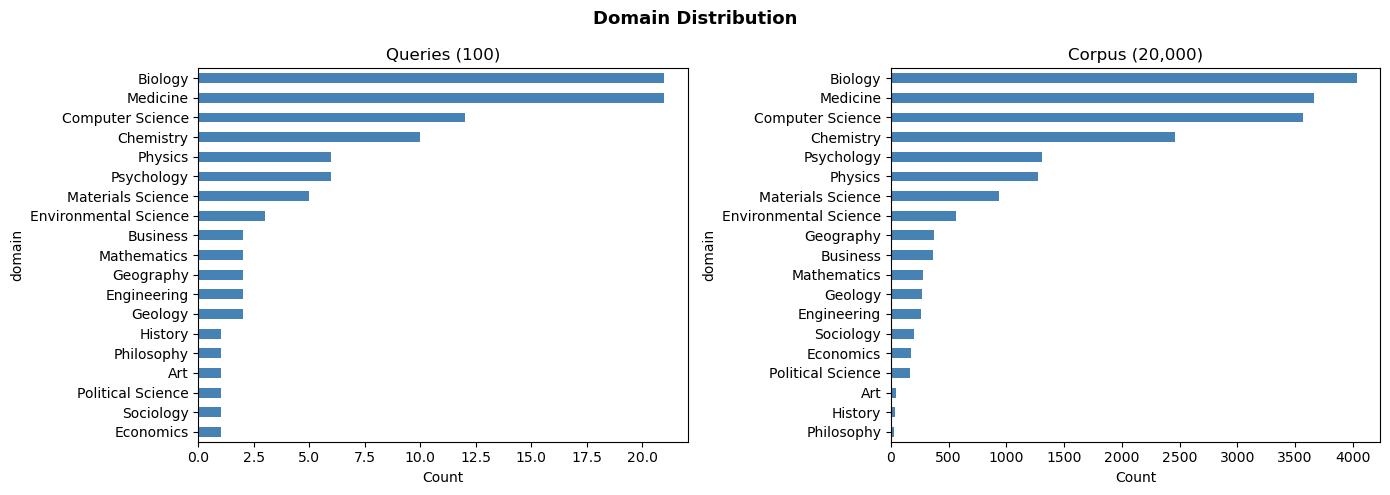

In [9]:
# Domain distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], queries, "Queries (100)"),
    (axes[1], corpus,  "Corpus (20,000)"),
]:
    counts = df["domain"].value_counts()
    counts.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.invert_yaxis()
plt.suptitle("Domain Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

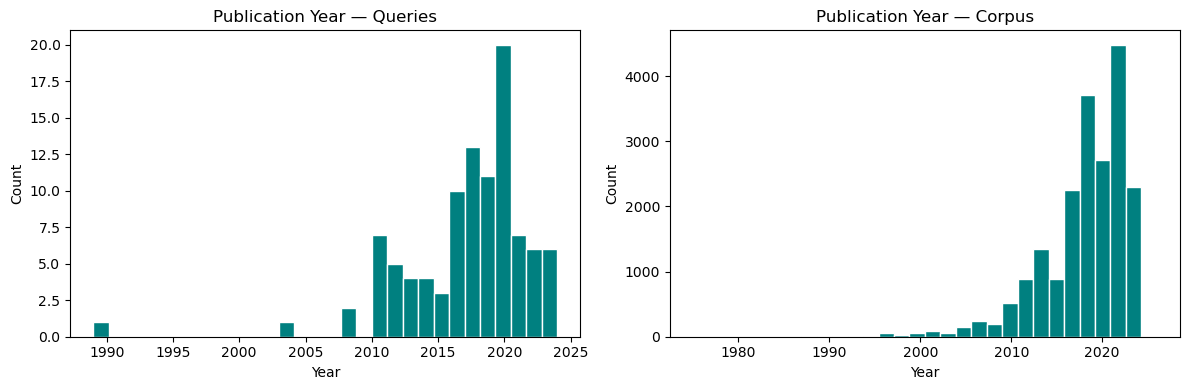

In [10]:
# Year distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in [
    (axes[0], queries, "Queries"),
    (axes[1], corpus,  "Corpus"),
]:
    years = df["year"].replace(0, np.nan).dropna()
    ax.hist(years, bins=30, color="teal", edgecolor="white")
    ax.set_title(f"Publication Year — {title}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.3 — Venue Statistics

Unique venues — corpus: 2,972   queries: 73


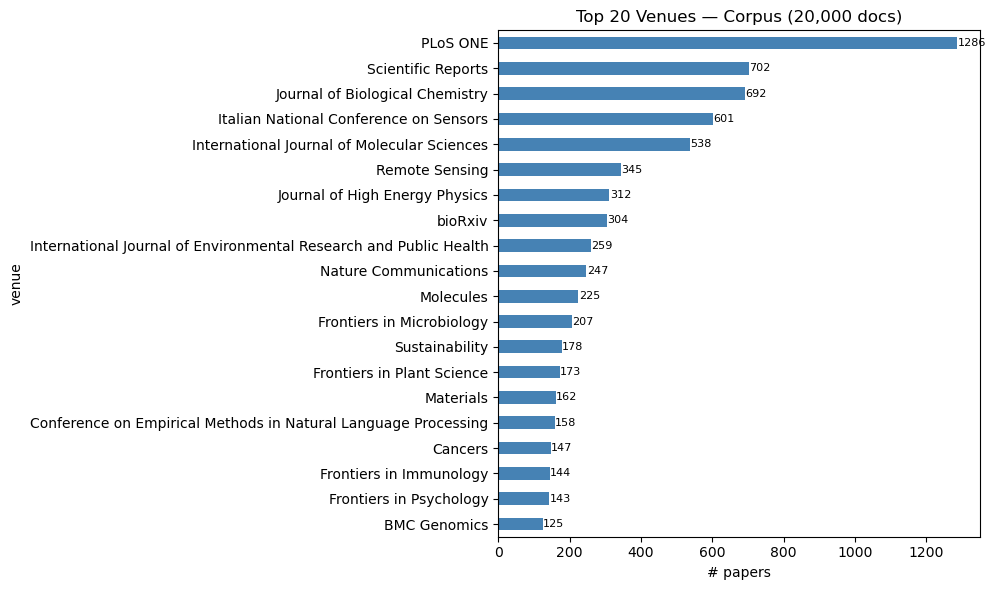


Top 3 venues per domain (5 largest domains):

  Biology:
     442  PLoS ONE
     309  Journal of Biological Chemistry
     169  International Journal of Molecular Sciences

  Medicine:
     241  PLoS ONE
     168  International Journal of Molecular Sciences
     108  Scientific Reports

  Computer Science:
     422  Italian National Conference on Sensors
     234  Remote Sensing
     157  Conference on Empirical Methods in Natural Language Processing

  Chemistry:
     299  Journal of Biological Chemistry
     155  PLoS ONE
     143  International Journal of Molecular Sciences

  Psychology:
     113  PLoS ONE
     100  Frontiers in Psychology
      68  International Journal of Environmental Research and Public Health


In [11]:
# Venue statistics
n_unique_corpus  = corpus["venue"].replace("", pd.NA).dropna().nunique()
n_unique_queries = queries["venue"].replace("", pd.NA).dropna().nunique()
print(f"Unique venues — corpus: {n_unique_corpus:,}   queries: {n_unique_queries:,}")

# Top 20 venues in corpus
top_venues = (
    corpus["venue"]
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_venues.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Venues — Corpus (20,000 docs)")
ax.set_xlabel("# papers")
ax.invert_yaxis()
for i, v in enumerate(top_venues):
    ax.text(v + 1, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Top venues per domain (top 3 venues for the 5 largest domains)
print("\nTop 3 venues per domain (5 largest domains):")
top5_domains = corpus["domain"].value_counts().head(5).index
for domain in top5_domains:
    top3 = (
        corpus[corpus["domain"] == domain]["venue"]
        .replace("", pd.NA).dropna()
        .value_counts().head(3)
    )
    print(f"\n  {domain}:")
    for venue, count in top3.items():
        print(f"    {count:>4}  {venue}")

### 1.2 — Citation & Relevance Stats

Gold docs per query:
  mean=7.36  median=3  min=2  max=71
  Queries with 1 gold  : 0
  Queries with 2–4     : 66
  Queries with 5+      : 34


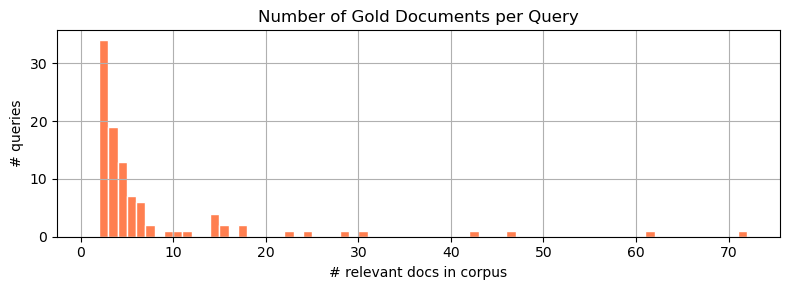

In [12]:
# Relevance distribution (how many gold docs per query?)
n_relevant = queries["n_relevant"]
print("Gold docs per query:")
print(f"  mean={n_relevant.mean():.2f}  median={n_relevant.median():.0f}  "
      f"min={n_relevant.min()}  max={n_relevant.max()}")
print(f"  Queries with 1 gold  : {(n_relevant == 1).sum()}")
print(f"  Queries with 2–4     : {((n_relevant >= 2) & (n_relevant <= 4)).sum()}")
print(f"  Queries with 5+      : {(n_relevant >= 5).sum()}")

fig, ax = plt.subplots(figsize=(8, 3))
n_relevant.hist(bins=range(1, n_relevant.max() + 2), ax=ax, color="coral", edgecolor="white")
ax.set_title("Number of Gold Documents per Query")
ax.set_xlabel("# relevant docs in corpus")
ax.set_ylabel("# queries")
plt.tight_layout()
plt.show()

In [13]:
# Verify all gold docs are present in corpus
corpus_id_set = set(corpus["doc_id"])
coverage = [
    sum(1 for d in docs if d in corpus_id_set) / len(docs)
    for docs in qrels.values() if docs
]
print(f"Average gold coverage in corpus : {np.mean(coverage):.1%}")
print(f"Queries with full coverage      : {sum(1 for c in coverage if c == 1.0)} / {len(coverage)}")

Average gold coverage in corpus : 100.0%
Queries with full coverage      : 100 / 100


### 1.3 — Title + Abstract Length Distribution

Queries TA length (chars):  mean=1524  median=1459  p5=663  p95=2344  max=3248
Corpus TA length (chars):  mean=1663  median=1592  p5=826  p95=2614  max=16514


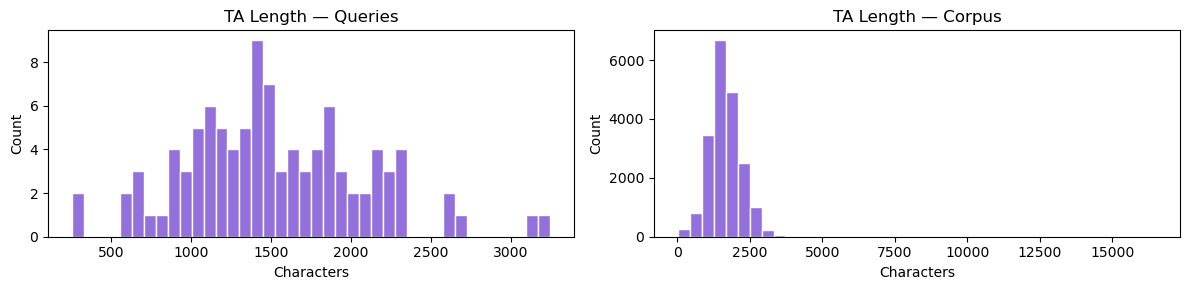

In [14]:
# TA length stats
for df, label in [(queries, "Queries"), (corpus, "Corpus")]:
    ta_len = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
    print(f"{label} TA length (chars):  mean={ta_len.mean():.0f}  "
          f"median={ta_len.median():.0f}  p5={ta_len.quantile(0.05):.0f}  "
          f"p95={ta_len.quantile(0.95):.0f}  max={ta_len.max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df, label in [(axes[0], queries, "Queries"), (axes[1], corpus, "Corpus")]:
    ta_len = (df["title"].fillna("") + " " + df["abstract"].fillna("")).str.len()
    ax.hist(ta_len, bins=40, color="mediumpurple", edgecolor="white")
    ax.set_title(f"TA Length — {label}")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.4 — Full-Text & Chunk Statistics

Each paper includes a `full_text` field (body text with paragraphs separated by `\n\n`) and a `chunk_meta` field encoding pre-computed section boundaries.  
Each entry has a `type` (`"ta"` or `"body"`) and a `char_start` offset into `full_text`.  
The `ta` entry additionally has `char_end`, so it can be sliced directly: `full_text[char_start:char_end]`.  
Body entries only have `char_start` — a section runs from its `char_start` to the next entry's `char_start` (or the end of `full_text` for the last section). The `get_chunks()` helper in Section 2 handles this automatically.

In [15]:
# Parse chunk_meta for all corpus docs
def parse_chunk_meta(cm_str):
    return json.loads(cm_str) if isinstance(cm_str, str) and cm_str else []

corpus_chunks = corpus["chunk_meta"].apply(parse_chunk_meta)
query_chunks  = queries["chunk_meta"].apply(parse_chunk_meta)

# Number of body chunks per paper (exclude the TA entry)
def n_body_chunks(meta):
    return sum(1 for e in meta if e.get("type") == "body")

corpus_n_body = corpus_chunks.apply(n_body_chunks)
query_n_body  = query_chunks.apply(n_body_chunks)

for label, s in [("Corpus", corpus_n_body), ("Queries", query_n_body)]:
    print(f"{label} body chunks/paper:  mean={s.mean():.1f}  "
          f"median={s.median():.0f}  min={s.min()}  max={s.max()}  "
          f"p5={s.quantile(0.05):.0f}  p95={s.quantile(0.95):.0f}")

Corpus body chunks/paper:  mean=10.8  median=9  min=2  max=156  p5=2  p95=24
Queries body chunks/paper:  mean=10.1  median=8  min=2  max=42  p5=2  p95=21


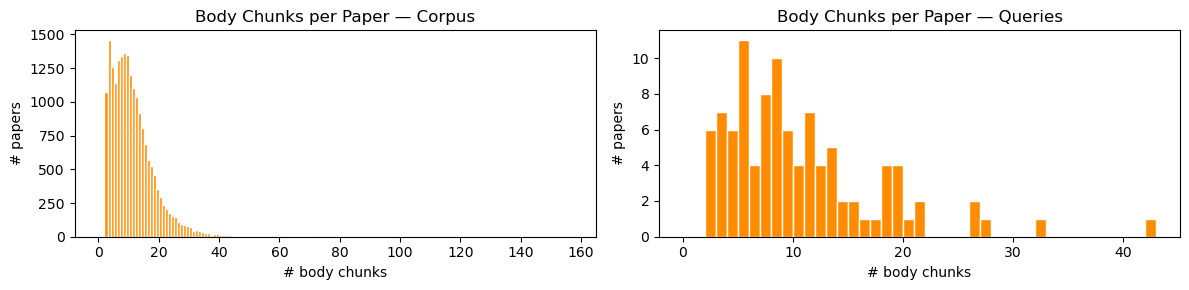

In [16]:
# Distribution of body chunk counts
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, s, label in [
    (axes[0], corpus_n_body, "Corpus"),
    (axes[1], query_n_body,  "Queries"),
]:
    ax.hist(s, bins=range(0, s.max() + 2), color="darkorange", edgecolor="white")
    ax.set_title(f"Body Chunks per Paper — {label}")
    ax.set_xlabel("# body chunks")
    ax.set_ylabel("# papers")
plt.tight_layout()
plt.show()

In [17]:
# Inspect chunks for a single paper
sample_row = corpus.iloc[0]
meta = parse_chunk_meta(sample_row["chunk_meta"])
full_text = sample_row["full_text"]

print(f"Paper: {sample_row['doc_id']}")
print(f"Title: {sample_row['title'][:80]}")
print(f"Total chunk entries: {len(meta)}  (1 TA + {len(meta)-1} body)\n")

for i, entry in enumerate(meta[:4]):   # show first 4 entries
    char_start = entry["char_start"]
    char_end   = entry.get("char_end") or (
        meta[i + 1]["char_start"] if i + 1 < len(meta) else len(full_text)
    )
    text = full_text[char_start:char_end].strip()
    print(f"[{i}] {entry['type'].upper()} chunk  chars {char_start}–{char_end}  ({char_end - char_start} chars)")
    print(f"    {text[:300]} ...")
    print()

Paper: f1c5e98774c4c7eb68496979cab2e57b8dcb2026
Title: Model-Observer Similarity, Error Modeling and Social Learning in Rhesus Macaques
Total chunk entries: 16  (1 TA + 15 body)

[0] TA chunk  chars 0–2033  (2033 chars)
    Model-Observer Similarity, Error Modeling and Social Learning in Rhesus Macaques

Monkeys readily learn to discriminate between rewarded and unrewarded items or actions by observing their conspecifics. However, they do not systematically learn from humans. Understanding what makes human-to-monkey tr ...

[1] BODY chunk  chars 8726–8876  (150 chars)
    Materials and Methods
The paragraphs below provide a brief description of the subjects and procedures. A more detailed account is available in [10]. ...

[2] BODY chunk  chars 8876–8946  (70 chars)
    Ethics
The study was carried out in strict accordance with Directive ...

[3] BODY chunk  chars 8946–9613  (667 chars)
    Enrichment
The animals housing quarters matched or exceeded the minimal surface, height, and vol

Corpus full_text length (chars): mean=39700  median=35956  p5=16622  p95=74762


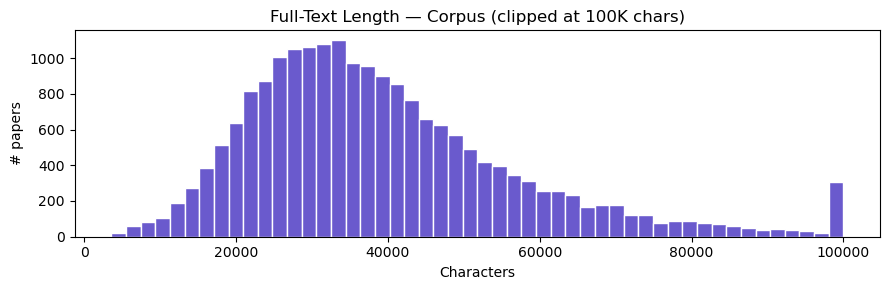

In [18]:
# Full-text length distribution (corpus)
ft_len = corpus["full_text"].str.len()
print(f"Corpus full_text length (chars): mean={ft_len.mean():.0f}  "
      f"median={ft_len.median():.0f}  p5={ft_len.quantile(0.05):.0f}  "
      f"p95={ft_len.quantile(0.95):.0f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(ft_len.clip(upper=100_000), bins=50, color="slateblue", edgecolor="white")
ax.set_title("Full-Text Length — Corpus (clipped at 100K chars)")
ax.set_xlabel("Characters")
ax.set_ylabel("# papers")
plt.tight_layout()
plt.show()

C:\Users\salma\AppData\Local\Temp\ipykernel_16360\3589960137.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_domain, labels=domain_order, patch_artist=True,


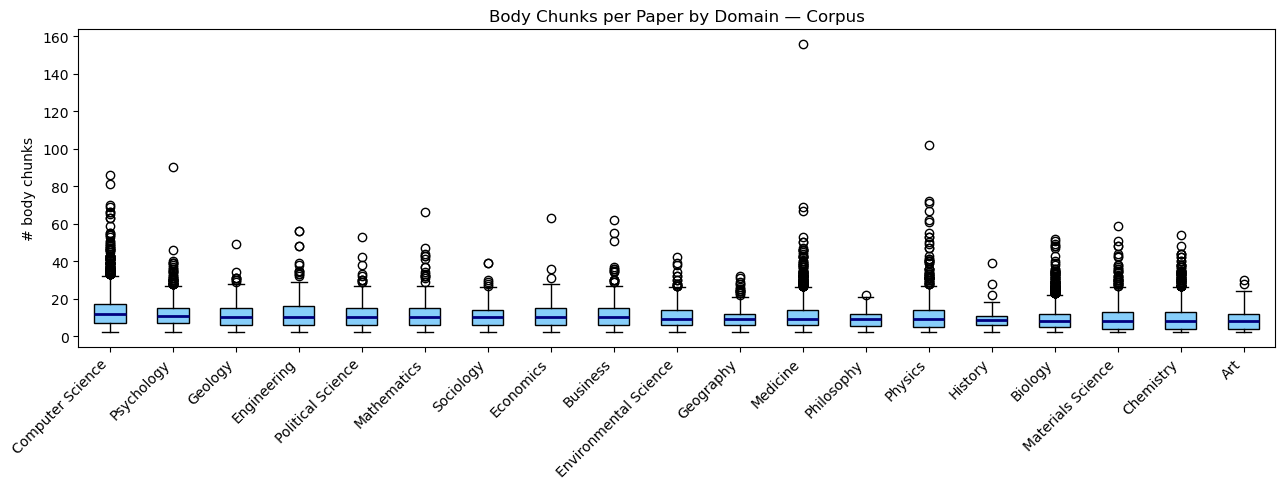


Domain                        Papers  Median chunks  Median section (chars)
---------------------------------------------------------------------------
Computer Science                3571             12                    1642
Psychology                      1306             10                    1583
Geology                          273             10                    2086
Engineering                      264             10                    1843
Political Science                168             10                    1889
Mathematics                      277             10                    1607
Sociology                        196             10                    2212
Economics                        173             10                    1967
Business                         363             10                    1782
Environmental Science            567              9                    1978
Geography                        375              9                    1895
Medicine   

In [19]:
# Body chunks per paper broken down by domain
corpus["n_body_chunks"] = corpus["chunk_meta"].apply(
    lambda cm: sum(1 for e in json.loads(cm) if e.get("type") == "body")
)

domain_order = corpus.groupby("domain")["n_body_chunks"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
data_by_domain = [corpus[corpus["domain"] == d]["n_body_chunks"].values for d in domain_order]
ax.boxplot(data_by_domain, labels=domain_order, patch_artist=True,
           boxprops=dict(facecolor="lightskyblue"), medianprops=dict(color="navy", linewidth=2))
ax.set_title("Body Chunks per Paper by Domain — Corpus")
ax.set_ylabel("# body chunks")
ax.set_xticklabels(domain_order, rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Median body chunks and section length per domain
print(f"\n{'Domain':<28}  {'Papers':>6}  {'Median chunks':>13}  {'Median section (chars)':>22}")
print("-" * 75)
for domain in domain_order:
    sub = corpus[corpus["domain"] == domain]
    med_chunks = sub["n_body_chunks"].median()
    section_lens = []
    for row in sub.itertuples():
        meta = json.loads(row.chunk_meta)
        body = [e for e in meta if e.get("type") == "body"]
        for j, e in enumerate(body):
            end = body[j + 1]["char_start"] if j + 1 < len(body) else len(row.full_text)
            section_lens.append(end - e["char_start"])
    med_sec = int(np.median(section_lens)) if section_lens else 0
    print(f"{domain:<28}  {len(sub):>6}  {med_chunks:>13.0f}  {med_sec:>22}")

---
## Section 2 — TF-IDF Baseline

A simple sparse retrieval baseline using TF-IDF cosine similarity over **title + abstract** only.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load data (re-load in case this section is run independently)
DATA_DIR = Path("../data")
#queries = load_queries(DATA_DIR / "../held_out_queries.parquet")
queries = load_queries(DATA_DIR / "queries.parquet")
corpus  = load_corpus(DATA_DIR / "corpus.parquet")
qrels   = load_qrels(DATA_DIR / "qrels.json")

query_ids  = queries["doc_id"].tolist()
corpus_ids = corpus["doc_id"].tolist()

# Use title + abstract for retrieval (TA only)
query_texts  = [format_text(row) for _, row in queries.iterrows()]
corpus_texts = [format_text(row) for _, row in corpus.iterrows()]

print(f"Queries : {len(query_texts)}")
print(f"Corpus  : {len(corpus_texts)}")

Queries : 100
Corpus  : 20000


In [21]:
# Build TF-IDF index on corpus TA
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 1),
    stop_words="english",
)
corpus_matrix = vectorizer.fit_transform(corpus_texts)   # (20000, vocab)
query_matrix  = vectorizer.transform(query_texts)        # (100, vocab)
print(f"Corpus matrix : {corpus_matrix.shape}  vocab={corpus_matrix.shape[1]:,}")
print(f"Query  matrix : {query_matrix.shape}")

Corpus matrix : (20000, 44105)  vocab=44,105
Query  matrix : (100, 44105)


In [22]:
# Retrieve top-100 per query
TOP_K = 100
sim_matrix = cosine_similarity(query_matrix, corpus_matrix)   # (100, 20000)

tfidf_submission = {}
for i, qid in enumerate(query_ids):
    top_indices = np.argsort(-sim_matrix[i])[:TOP_K]
    tfidf_submission[qid] = [corpus_ids[j] for j in top_indices]

print(f"Submission: {len(tfidf_submission)} queries × {TOP_K} results")

Submission: 100 queries × 100 results


In [23]:
# Evaluate
query_domains = dict(zip(queries["doc_id"], queries["domain"]))
tfidf_results = evaluate(tfidf_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


OVERALL RESULTS
Recall          @ 10: 0.4445  @100: 0.7512
Precision       @ 10: 0.2270  @100: 0.0528
MRR             @ 10: 0.6655  @100: 0.6713
NDCG            @ 10: 0.4841  @100: 0.5594
MAP             0.3804
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n
  Art                          0.500 0.200 1.000   0.508  0.306  1
  Biology                      0.415 0.205 0.664   0.436  0.324  21
  Business                     0.500 0.350 0.750   0.562  0.456  2
  Chemistry                    0.404 0.360 0.770   0.551  0.383  10
  Computer Science             0.267 0.242 0.526   0.396  0.318  12
  Economics                    0.294 0.500 1.000   0.633  0.424  1
  Engineering                  0.250 0.100 0.583   0.265  0.175  2
  Environmental Science        0.624 0.433 0.778   0.667  0.

In [24]:
# ── TODO 2 ───────────────────────────────────────────────────────────────────
# Pick any query and inspect its top-5 TF-IDF results.
selected_qid = query_ids[0]
top_docs = tfidf_submission[selected_qid][:5]
gold_docs = set(qrels.get(selected_qid, []))
query_row = queries[queries["doc_id"] == selected_qid].iloc[0]
print("Query title: "+ query_row["title"])
# For each retrieved document, print its title and whether it is a gold doc.
print("\nTop-5 retrieved documents:\n")
for rank, doc_id in enumerate(top_docs, start=1):
    doc_row = corpus[corpus["doc_id"] == doc_id].iloc[0]
    is_gold = doc_id in gold_docs
    
    print(f"{rank}. [{doc_id}] {doc_row['title']}")
    print(f"    Gold: {'Gold Doc' if is_gold else 'Not Gold Doc'}\n")
#
# Hint: tfidf_submission[qid] gives the ranked list of doc IDs for that query.
#       qrels[qid] gives the set of gold doc IDs.
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE

Query title: Ecotypic Morphological and Physio-Biochemical Responses of Two Differentially Adapted Forage Grasses, Cenchrus ciliaris L. and Cyperus arenarius Retz. to Drought Stress

Top-5 retrieved documents:

1. [5330446c9ce825a30a2203f662cea725009e7e7b] Plant growth promoting rhizobacteria alleviates drought stress in potato in response to suppressive oxidative stress and antioxidant enzymes activities
    Gold: Not Gold Doc

2. [c929c327882ddae690e808e55771227930933b53] Comparative physiological and biochemical mechanisms of salt tolerance in five contrasting highland quinoa cultivars
    Gold: Gold Doc

3. [a93d7533e0ca8f778c218a1f5a489228e2d8042c] Differential Morphophysiological, Biochemical, and Molecular Responses of Maize Hybrids to Salinity and Alkalinity Stresses
    Gold: Not Gold Doc

4. [298f411bdcc0a8ee016c415b519789ce847c8b1c] Effects of salinity and drought on growth, ionic relations, compatible solutes and activation of antioxidant systems in oleander (Nerium oleande

In [25]:
# Save submission
os.makedirs("../submissions", exist_ok=True)
with open("../submissions/submissiom_data.json", "w") as f:
    json.dump(tfidf_submission, f)
print("Saved → ../submissions/submissiom_data.json")

Saved → ../submissions/submissiom_data.json


---
## Section 3 — Dense Retrieval Baseline

Dense retrieval using pre-computed embeddings from [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) (22M params).  
Texts were encoded as `title + " " + abstract`. Embeddings are L2-normalised → cosine similarity = dot product.  
To re-encode with a different model, run `scripts/embed.py --model <model-name>`.

In [26]:
EMB_DIR = DATA_DIR / "embeddings" / "sentence-transformers_all-MiniLM-L6-v2"

for f in ["query_embeddings.npy", "corpus_embeddings.npy",
          "query_ids.json", "corpus_ids.json", "model_info.txt"]:
    path = EMB_DIR / f
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status}  {path}")

if (EMB_DIR / "model_info.txt").exists():
    print("\nModel info:")
    print((EMB_DIR / "model_info.txt").read_text())

  ✓  ..\data\embeddings\sentence-transformers_all-MiniLM-L6-v2\query_embeddings.npy
  ✓  ..\data\embeddings\sentence-transformers_all-MiniLM-L6-v2\corpus_embeddings.npy
  ✓  ..\data\embeddings\sentence-transformers_all-MiniLM-L6-v2\query_ids.json
  ✓  ..\data\embeddings\sentence-transformers_all-MiniLM-L6-v2\corpus_ids.json
  ✓  ..\data\embeddings\sentence-transformers_all-MiniLM-L6-v2\model_info.txt

Model info:
model: sentence-transformers/all-MiniLM-L6-v2
embedding_dim: 384
normalize_embeddings: True
text_format: title + ' ' + abstract



In [27]:
# Load embeddings
query_embs, q_ids = load_embeddings(EMB_DIR / "query_embeddings.npy",
                                     EMB_DIR / "query_ids.json")
corpus_embs, c_ids = load_embeddings(EMB_DIR / "corpus_embeddings.npy",
                                      EMB_DIR / "corpus_ids.json")
print(f"Query  embeddings : {query_embs.shape}")
print(f"Corpus embeddings : {corpus_embs.shape}")

Query  embeddings : (100, 384)
Corpus embeddings : (20000, 384)


In [28]:
# Dense retrieval
TOP_K = 100

# ── TODO 3 ───────────────────────────────────────────────────────────────────
# Compute the cosine similarity matrix between all queries and all corpus docs.
# The embeddings are already L2-normalised, so cosine similarity = dot product.
# sim_matrix should have shape (n_queries, n_corpus).
#
# Hint: use matrix multiplication between query_embs and corpus_embs.
# ─────────────────────────────────────────────────────────────────────────────
# YOUR CODE HERE
sim_matrix = np.dot(query_embs, corpus_embs.T)  
top_indices = np.argsort(-sim_matrix, axis=1)[:, :TOP_K]      
dense_submission = {qid: [c_ids[j] for j in top_indices[i]]
                    for i, qid in enumerate(q_ids)}
print(f"Submission: {len(dense_submission)} queries × {TOP_K} results")

Submission: 100 queries × 100 results


In [29]:
# Evaluate
dense_results = evaluate(dense_submission, qrels, ks=[10, 100],
                         query_domains=query_domains, verbose=True)


OVERALL RESULTS
Recall          @ 10: 0.4716  @100: 0.8104
Precision       @ 10: 0.2440  @100: 0.0587
MRR             @ 10: 0.6812  @100: 0.6834
NDCG            @ 10: 0.5073  @100: 0.5903
MAP             0.4080
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n
  Art                          0.500 0.200 1.000   0.586  0.417  1
  Biology                      0.459 0.214 0.734   0.471  0.362  21
  Business                     0.400 0.400 0.562   0.471  0.415  2
  Chemistry                    0.333 0.330 0.682   0.473  0.320  10
  Computer Science             0.323 0.300 0.549   0.447  0.374  12
  Economics                    0.412 0.700 1.000   0.792  0.539  1
  Engineering                  0.250 0.100 0.750   0.318  0.230  2
  Environmental Science        0.557 0.400 0.548   0.522  0.

In [30]:
# Summary comparison
comparison = []
for name, res in [("TF-IDF", tfidf_results), ("all-MiniLM-L6-v2", dense_results)]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
pd.DataFrame(comparison).set_index("Model")

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
all-MiniLM-L6-v2,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080


In [31]:
# Save dense submission
with open("../submissions/dense_minilm.json", "w") as f:
    json.dump(dense_submission, f)
print("Saved → ../submissions/dense_minilm.json")

Saved → ../submissions/dense_minilm.json


---
## Section 5 — 8-Signal Optimized Fusion (NDCG@10 = 0.7373)

Combines 8 retrieval signals with coordinate-descent-optimized weights:
1. **Dense MiniLM** — precomputed cosine similarity (TA)
2. **Dense BGE-small** — second dense encoder for ensemble diversity
3. **BM25-Body (query=Full)** — BM25 over body sections, using full query text
4. **BM25-Full (query=Full)** — BM25 over TA+body, using full query text
5. **TF-IDF-Full (query=TA)** — TF-IDF cosine over TA+body corpus
6. **TF-IDF-Full (query=Full)** — TF-IDF cosine, full-text queries
7. **Domain Match** — binary: same domain as query
8. **Venue Match** — binary: same venue as query

In [32]:
import sys
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sys.path.insert(0, str(Path("../scripts").resolve()))
from retrieval_improvements import (
    bm25_score_matrix, get_body_texts, get_chunks,
    normalize_score_rows, scores_to_submission,
)
norm = normalize_score_rows

# TA + body
def build_full_texts(df):
    texts = []
    for _, row in df.iterrows():
        ta = format_text(row)
        chunks = get_chunks(row["full_text"], row["chunk_meta"])
        body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
        texts.append(ta + " " + body)
    return texts

corpus_full_texts = build_full_texts(corpus)
query_full_texts = build_full_texts(queries)
body_texts = get_body_texts(corpus, min_chars=100)

print(f"Corpus full texts: {len(corpus_full_texts)}")
print(f"Query full texts:  {len(query_full_texts)}")
print(f"Body texts:        {len(body_texts)}")

Corpus full texts: 20000
Query full texts:  100
Body texts:        20000


In [33]:
import sys
from sklearn.feature_extraction.text import CountVectorizer

sys.path.append(str(Path("../scripts").resolve()))
from retrieval_improvements import bm25_retrieve_from_counts

ta_vectorizer = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
ta_corpus_counts = ta_vectorizer.fit_transform(corpus_texts)
ta_query_counts = ta_vectorizer.transform(query_texts)

bm25_submission = bm25_retrieve_from_counts(
    ta_corpus_counts,
    ta_query_counts,
    corpus_ids,
    query_ids,
    k1=1.5,
    b=0.75,
    top_k=100,
)

print("\n****************************** BM25 (TA) Results ******************************")
print({"vocab_size": len(ta_vectorizer.vocabulary_), "k1": 1.5, "b": 0.75})
bm25_results = evaluate(bm25_submission, qrels, verbose=True)

comparison_bm25_tfidf = []
for name, res in [("TF-IDF", tfidf_results), ("BM25 (TA)", bm25_results)]:
    row = {"Model": name}
    row.update({
        k: f"{v:.4f}"
        for k, v in res["overall"].items()
        if k != "num_queries"
    })
    comparison_bm25_tfidf.append(row)

pd.DataFrame(comparison_bm25_tfidf).set_index("Model")



****************************** BM25 (TA) Results ******************************
{'vocab_size': 44105, 'k1': 1.5, 'b': 0.75}

OVERALL RESULTS
Recall          @ 10: 0.4186  @100: 0.7154
Precision       @ 10: 0.2190  @100: 0.0502
MRR             @ 10: 0.6360  @100: 0.6399
NDCG            @ 10: 0.4555  @100: 0.5247
MAP             0.3473
Queries         100



,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
BM25 (TA),0.4186,0.2190,0.6360,0.4555,0.7154,0.0502,0.6399,0.5247,0.3473


In [34]:
print("\n****************************** BM25 (TA) Results After Small Tuning ******************************")

k1_values = [1.2, 1.5, 1.8]
b_values = [0.5, 0.75, 0.9]

best_score = -1
best_results = None
best_params = None
best_submission = None

for k1 in k1_values:
    for b in b_values:
        submission = bm25_retrieve_from_counts(
            ta_corpus_counts,
            ta_query_counts,
            corpus_ids,
            query_ids,
            k1=k1,
            b=b,
            top_k=100,
        )
        results = evaluate(submission, qrels, verbose=False)
        combined = results["overall"]["Recall@100"] + results["overall"]["NDCG@10"] + results["overall"]["MAP"]

        print(
            f'k1={k1}, b={b} -> Recall@100={results["overall"]["Recall@100"]:.4f}  '
            f'NDCG@10={results["overall"]["NDCG@10"]:.4f}  MAP={results["overall"]["MAP"]:.4f}'
        )

        if combined > best_score:
            best_score = combined
            best_results = results
            best_params = {"k1": k1, "b": b}
            best_submission = submission

bm25_tuned_results = best_results
bm25_tuned_submission = best_submission
print("\nBest params:", best_params)

comparison = []
for name, res in [("TF-IDF", tfidf_results), ("BM25 (TA) default", bm25_results), ("BM25 (TA) tuned", bm25_tuned_results)]:
    row = {"Model": name}
    row.update({
        k: f"{v:.4f}"
        for k, v in res["overall"].items()
        if k != "num_queries"
    })
    comparison.append(row)

pd.DataFrame(comparison).set_index("Model")



****************************** BM25 (TA) Results After Small Tuning ******************************
k1=1.2, b=0.5 -> Recall@100=0.7041  NDCG@10=0.4517  MAP=0.3452
k1=1.2, b=0.75 -> Recall@100=0.7127  NDCG@10=0.4603  MAP=0.3490
k1=1.2, b=0.9 -> Recall@100=0.7192  NDCG@10=0.4659  MAP=0.3547
k1=1.5, b=0.5 -> Recall@100=0.7092  NDCG@10=0.4471  MAP=0.3434
k1=1.5, b=0.75 -> Recall@100=0.7154  NDCG@10=0.4555  MAP=0.3473
k1=1.5, b=0.9 -> Recall@100=0.7216  NDCG@10=0.4607  MAP=0.3536
k1=1.8, b=0.5 -> Recall@100=0.7088  NDCG@10=0.4441  MAP=0.3420
k1=1.8, b=0.75 -> Recall@100=0.7143  NDCG@10=0.4546  MAP=0.3473
k1=1.8, b=0.9 -> Recall@100=0.7251  NDCG@10=0.4630  MAP=0.3561

Best params: {'k1': 1.8, 'b': 0.9}


,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
BM25 (TA) default,0.4186,0.2190,0.6360,0.4555,0.7154,0.0502,0.6399,0.5247,0.3473
BM25 (TA) tuned,0.4257,0.2210,0.6430,0.4630,0.7251,0.0507,0.6470,0.5333,0.3561


In [35]:
import sys
sys.path.append(str(Path("../scripts").resolve()))

from retrieval_improvements import (
    bm25_score_matrix,
    get_body_texts,
    normalize_score_rows,
   
    scores_to_submission,
)


In [36]:
body_texts = get_body_texts(corpus, min_chars=100)
body_vectorizer = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
body_corpus_counts = body_vectorizer.fit_transform(body_texts)
body_query_counts = body_vectorizer.transform(query_texts)

body_default_scores = bm25_score_matrix(body_corpus_counts, body_query_counts, k1=1.2, b=0.7)
full_submission = scores_to_submission(body_default_scores, corpus_ids, query_ids, top_k=100)
full_meta = {
    "min_chars": 100,
    "min_df": 2,
    "max_df": 0.95,
    "k1": 1.2,
    "b": 0.7,
    "top_k": 100,
    "vocab_size": len(body_vectorizer.vocabulary_),
}

print("\n****************************** BM25 (Body Text) Results ******************************")
print(full_meta)
full_results = evaluate(full_submission, qrels, verbose=True)

comparison = []
for name, res in [
    ("TF-IDF", tfidf_results),
    ("Dense MiniLM", dense_results),
    ("BM25 (TA)", bm25_tuned_results),
    ("BM25 (Body)", full_results),
]:
    row = {"Model": name}
    row.update({
        k: f"{v:.4f}"
        for k, v in res["overall"].items()
        if k != "num_queries"
    })
    comparison.append(row)

pd.DataFrame(comparison).set_index("Model")


****************************** BM25 (Body Text) Results ******************************
{'min_chars': 100, 'min_df': 2, 'max_df': 0.95, 'k1': 1.2, 'b': 0.7, 'top_k': 100, 'vocab_size': 214897}

OVERALL RESULTS
Recall          @ 10: 0.4353  @100: 0.7678
Precision       @ 10: 0.2330  @100: 0.0554
MRR             @ 10: 0.6696  @100: 0.6763
NDCG            @ 10: 0.4843  @100: 0.5629
MAP             0.3837
Queries         100



,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF,0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
Dense MiniLM,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080
BM25 (TA),0.4257,0.2210,0.6430,0.4630,0.7251,0.0507,0.6470,0.5333,0.3561
BM25 (Body),0.4353,0.2330,0.6696,0.4843,0.7678,0.0554,0.6763,0.5629,0.3837


In [37]:
print("\n****************************** BM25 (Body Text) Tuned ******************************")
body_k1_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
body_b_values = [0.3, 0.5, 0.7, 0.9]

body_runs = []
best_body_score = -1
best_body_params = None
best_body_results = None
best_body_submission = None
best_body_scores = None

for k1 in body_k1_values:
    for b in body_b_values:
        score_matrix = bm25_score_matrix(body_corpus_counts, body_query_counts, k1=k1, b=b)
        submission = scores_to_submission(score_matrix, corpus_ids, query_ids, top_k=100)
        results = evaluate(submission, qrels, verbose=False)
        combined = results["overall"]["Recall@100"] + results["overall"]["NDCG@10"] + results["overall"]["MAP"]
        body_runs.append({
            "k1": k1,
            "b": b,
            "Recall@100": results["overall"]["Recall@100"],
            "NDCG@10": results["overall"]["NDCG@10"],
            "MAP": results["overall"]["MAP"],
            "combined": combined,
        })
        print(
            f'k1={k1}, b={b} -> Recall@100={results["overall"]["Recall@100"]:.4f}  '
            f'NDCG@10={results["overall"]["NDCG@10"]:.4f}  MAP={results["overall"]["MAP"]:.4f}'
        )
        if combined > best_body_score:
            best_body_score = combined
            best_body_params = {"k1": k1, "b": b}
            best_body_results = results
            best_body_submission = submission
            best_body_scores = score_matrix

print("\nBest body params:", best_body_params)
body_runs_df = pd.DataFrame(body_runs).sort_values("combined", ascending=False)
display(body_runs_df.head(10))

print("\n****************************** Dense Improvement via 3-Way Score Interpolation ******************************")
dense_score_matrix = np.dot(query_embs, corpus_embs.T)
norm_dense_scores = normalize_score_rows(dense_score_matrix)
tfidf_score_matrix = cosine_similarity(query_matrix, corpus_matrix)
norm_tfidf_scores = normalize_score_rows(tfidf_score_matrix)

interp_runs = []
best_interp_score = -1
best_interp_params = None
best_interp_results = None
best_interp_submission = None

for alpha_dense in [0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
    for alpha_body in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
        alpha_tfidf = 1.0 - alpha_dense - alpha_body
        if alpha_tfidf < 0.05:
            continue
        mixed_scores = (
            alpha_dense * norm_dense_scores
            + alpha_body * normalize_score_rows(best_body_scores)
            + alpha_tfidf * norm_tfidf_scores
        )
        submission = scores_to_submission(mixed_scores, corpus_ids, query_ids, top_k=100)
        results = evaluate(submission, qrels, verbose=False)
        combined = results["overall"]["Recall@100"] + results["overall"]["NDCG@10"] + results["overall"]["MAP"]
        interp_runs.append({
            "alpha_dense": alpha_dense,
            "alpha_body": alpha_body,
            "alpha_tfidf": alpha_tfidf,
            "Recall@100": results["overall"]["Recall@100"],
            "NDCG@10": results["overall"]["NDCG@10"],
            "MAP": results["overall"]["MAP"],
            "combined": combined,
        })
        if combined > best_interp_score:
            best_interp_score = combined
            best_interp_params = {
                "alpha_dense": alpha_dense,
                "alpha_body": alpha_body,
                "alpha_tfidf": alpha_tfidf,
            }
            best_interp_results = results
            best_interp_submission = submission

interp_runs_df = pd.DataFrame(interp_runs).sort_values("combined", ascending=False)
print("Best dense interpolation:", best_interp_params)
display(interp_runs_df.head(10))

print("\n****************************** Final Best Hybrid ******************************")
def rrf_fuse(submissions, query_ids, k=60, top_k=100):
    fused = {}
    for qid in query_ids:
        scores = {}
        for submission in submissions:
            docs = submission.get(qid, [])  # ✅ safe access
            for rank, doc_id in enumerate(docs, start=1):
                scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
        fused[qid] = [
            doc_id
            for doc_id, _ in sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        ]
    return fused
    
hybrid_rrf_submission = rrf_fuse([dense_submission, full_submission], query_ids=query_ids, k=60, top_k=100)
hybrid_rrf_results = evaluate(hybrid_rrf_submission, qrels, verbose=False)
hybrid_submission = best_interp_submission
hybrid_results = evaluate(hybrid_submission, qrels, verbose=True)

comparison = []
for name, res in [
    ("Dense MiniLM", dense_results),
    ("BM25 (Body) tuned", best_body_results),
    ("Hybrid RRF", hybrid_rrf_results),
    ("Dense + Body + TF-IDF Interp", hybrid_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)

pd.DataFrame(comparison).set_index("Model")

hybrid_gains = {
    metric: hybrid_results["overall"][metric] - dense_results["overall"][metric]
    for metric in ["NDCG@10", "Recall@100", "MAP"]
}
print("\nBest dense-improved gains vs Dense MiniLM:", {k: round(v, 4) for k, v in hybrid_gains.items()})


****************************** BM25 (Body Text) Tuned ******************************
k1=0.8, b=0.3 -> Recall@100=0.6983  NDCG@10=0.4546  MAP=0.3563
k1=0.8, b=0.5 -> Recall@100=0.7245  NDCG@10=0.4686  MAP=0.3690
k1=0.8, b=0.7 -> Recall@100=0.7464  NDCG@10=0.4768  MAP=0.3777
k1=0.8, b=0.9 -> Recall@100=0.7676  NDCG@10=0.4854  MAP=0.3854
k1=1.0, b=0.3 -> Recall@100=0.7130  NDCG@10=0.4599  MAP=0.3615
k1=1.0, b=0.5 -> Recall@100=0.7389  NDCG@10=0.4712  MAP=0.3749
k1=1.0, b=0.7 -> Recall@100=0.7594  NDCG@10=0.4786  MAP=0.3802
k1=1.0, b=0.9 -> Recall@100=0.7730  NDCG@10=0.4902  MAP=0.3923
k1=1.2, b=0.3 -> Recall@100=0.7245  NDCG@10=0.4647  MAP=0.3642
k1=1.2, b=0.5 -> Recall@100=0.7529  NDCG@10=0.4723  MAP=0.3748
k1=1.2, b=0.7 -> Recall@100=0.7678  NDCG@10=0.4843  MAP=0.3837
k1=1.2, b=0.9 -> Recall@100=0.7729  NDCG@10=0.4945  MAP=0.4000
k1=1.5, b=0.3 -> Recall@100=0.7289  NDCG@10=0.4663  MAP=0.3679
k1=1.5, b=0.5 -> Recall@100=0.7596  NDCG@10=0.4766  MAP=0.3780
k1=1.5, b=0.7 -> Recall@100=0.77

,k1,b,Recall@100,NDCG@10,MAP,combined
23,2.0,0.9,0.796118,0.517116,0.417077,1.730311
19,1.8,0.9,0.791476,0.516774,0.414647,1.722897
15,1.5,0.9,0.790245,0.505252,0.406081,1.701578
22,2.0,0.7,0.785747,0.497020,0.403707,1.686475
18,1.8,0.7,0.785414,0.496717,0.400961,1.683092
11,1.2,0.9,0.772914,0.494523,0.400011,1.667448
14,1.5,0.7,0.770659,0.495828,0.397024,1.663511
7,1.0,0.9,0.773011,0.490191,0.392292,1.655494
21,2.0,0.5,0.767619,0.486318,0.387596,1.641533
3,0.8,0.9,0.767583,0.485410,0.385367,1.638360



****************************** Dense Improvement via 3-Way Score Interpolation ******************************
Best dense interpolation: {'alpha_dense': 0.6, 'alpha_body': 0.3, 'alpha_tfidf': 0.10000000000000003}


,alpha_dense,alpha_body,alpha_tfidf,Recall@100,NDCG@10,MAP,combined
24,0.60,0.30,0.10,0.850174,0.591639,0.477397,1.919209
13,0.50,0.40,0.10,0.849858,0.591338,0.475387,1.916583
6,0.45,0.40,0.15,0.851085,0.588541,0.475120,1.914746
29,0.65,0.25,0.10,0.851640,0.587708,0.474297,1.913645
33,0.70,0.25,0.05,0.852890,0.583868,0.474820,1.911579
19,0.55,0.35,0.10,0.850353,0.586254,0.474474,1.911081
12,0.50,0.35,0.15,0.852397,0.584744,0.472268,1.909409
18,0.55,0.30,0.15,0.854484,0.581331,0.473246,1.909060
17,0.55,0.25,0.20,0.855241,0.581509,0.471892,1.908641
23,0.60,0.25,0.15,0.854976,0.581430,0.470992,1.907398



****************************** Final Best Hybrid ******************************

OVERALL RESULTS
Recall          @ 10: 0.5638  @100: 0.8502
Precision       @ 10: 0.2830  @100: 0.0621
MRR             @ 10: 0.7656  @100: 0.7690
NDCG            @ 10: 0.5916  @100: 0.6599
MAP             0.4774
Queries         100


Best dense-improved gains vs Dense MiniLM: {'NDCG@10': 0.0843, 'Recall@100': 0.0398, 'MAP': 0.0694}


In [38]:
held_out = pd.read_parquet(DATA_DIR / "queries.parquet")
# held_out = load_queries(DATA_DIR / "../held_out_queries.parquet")
ho_ids = held_out["doc_id"].tolist()

corpus_body_texts = get_body_texts(corpus, min_chars=100)

corpus_full_texts = []
for _, row in corpus.iterrows():
    ta = format_text(row)
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
    corpus_full_texts.append(ta + " " + body)

# TA + body
query_full_texts = []
for _, row in queries.iterrows():
    ta = format_text(row)
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
    query_full_texts.append(ta + " " + body)

ho_ta_texts = [format_text(row) for _, row in held_out.iterrows()]
ho_full_texts = []
for _, row in held_out.iterrows():
    ta = format_text(row)
    chunks = get_chunks(row["full_text"], row["chunk_meta"])
    body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
    ho_full_texts.append(ta + " " + body)

ho_embs = np.load(EMB_DIR / "held_out_query_embeddings.npy").astype(np.float32)

print(f"Corpus body texts : {len(corpus_body_texts)}")
print(f"Corpus full texts : {len(corpus_full_texts)}")
print(f"Query full texts  : {len(query_full_texts)}")
print(f"Held-out queries  : {len(ho_ids)}")
print(f"Held-out embeddings: {ho_embs.shape}")

Corpus body texts : 20000
Corpus full texts : 20000
Query full texts  : 100
Held-out queries  : 100
Held-out embeddings: (100, 384)


In [39]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def normalize_score_rows(score_matrix):
    row_min = score_matrix.min(axis=1, keepdims=True)
    row_max = score_matrix.max(axis=1, keepdims=True)
    denom = np.where(row_max > row_min, row_max - row_min, 1.0)
    return (score_matrix - row_min) / denom

BGE_DIR = DATA_DIR / "embeddings" / "BAAI_bge-small-en-v1.5"

# Signal 1: Dense MiniLM
dense_scores = np.dot(query_embs, corpus_embs.T)
sig_dense = normalize_score_rows(dense_scores)
print("Signal 1: Dense MiniLM")

# Signal 2: Dense BGE
bge_q = np.load(BGE_DIR / "query_embeddings.npy").astype(np.float32)
bge_c = np.load(BGE_DIR / "corpus_embeddings.npy").astype(np.float32)
sig_bge = normalize_score_rows(bge_q @ bge_c.T)
print("Signal 2: Dense BGE")

# Signal 3: BM25-Body (query=Full)
body_cv = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
body_corpus_c = body_cv.fit_transform(body_texts)
bm25_body_scores = bm25_score_matrix(
    body_corpus_c,
    body_cv.transform(query_full_texts),
    k1=3.0,
    b=0.95
)
sig_bm25_body = normalize_score_rows(bm25_body_scores)
print("Signal 3: BM25-Body (query=Full)")

# Signal 4: BM25-Full (query=Full)
full_cv = CountVectorizer(min_df=2, max_df=0.95, stop_words="english")
full_corpus_c = full_cv.fit_transform(corpus_full_texts)
bm25_full_scores = bm25_score_matrix(
    full_corpus_c,
    full_cv.transform(query_full_texts),
    k1=3.0,
    b=0.85
)
sig_bm25_full = normalize_score_rows(bm25_full_scores)
print("Signal 4: BM25-Full (query=Full)")

# Signal 5: TF-IDF-Full (query=TA)
tfidf_full_vec = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    stop_words="english"
)
tfidf_full_corpus = tfidf_full_vec.fit_transform(corpus_full_texts)
tfidf_scores = cosine_similarity(
    tfidf_full_vec.transform(query_texts),
    tfidf_full_corpus
)
sig_tfidf = normalize_score_rows(tfidf_scores)
print("Signal 5: TF-IDF-Full (query=TA)")

# Signal 6: TF-IDF-Full (query=Full)
tfidf_qfull_scores = cosine_similarity(
    tfidf_full_vec.transform(query_full_texts),
    tfidf_full_corpus
)
sig_tfidf_qfull = normalize_score_rows(tfidf_qfull_scores)
print("Signal 6: TF-IDF-Full (query=Full)")

# Signal 7: Domain Match
q_domains = np.array(queries["domain"].tolist())
c_domains = np.array(corpus["domain"].tolist())
domain_match = (q_domains[:, None] == c_domains[None, :]).astype(np.float32)
print(f"Signal 7: Domain Match (density={domain_match.mean():.4f})")

# Signal 8: Venue Match
q_venues = np.array(queries["venue"].fillna("").tolist())
c_venues = np.array(corpus["venue"].fillna("").tolist())
venue_match = (
    (q_venues[:, None] == c_venues[None, :]) &
    (q_venues[:, None] != "")
).astype(np.float32)
print(f"Signal 8: Venue Match (density={venue_match.mean():.4f})")

print("\nAll 8 signals built.")

Signal 1: Dense MiniLM
Signal 2: Dense BGE
Signal 3: BM25-Body (query=Full)
Signal 4: BM25-Full (query=Full)
Signal 5: TF-IDF-Full (query=TA)
Signal 6: TF-IDF-Full (query=Full)
Signal 7: Domain Match (density=0.1273)
Signal 8: Venue Match (density=0.0118)

All 8 signals built.


In [40]:
# Fuse with optimized weights (from coordinate descent)
w = {
    "domain":           0.237,
    "dense":            0.236,
    "bge":              0.151,
    "tfidf_full_qfull": 0.119,
    "tfidf_full":       0.114,
    "bm25_body_full":   0.091,
    "venue":            0.047,
    "bm25_full_full":   0.006,
}
sigs = {
    "dense": sig_dense, "bge": sig_bge,
    "bm25_body_full": sig_bm25_body, "bm25_full_full": sig_bm25_full,
    "tfidf_full": sig_tfidf, "tfidf_full_qfull": sig_tfidf_qfull,
    "domain": domain_match, "venue": venue_match,
}

mixed = sum(w[k] * sigs[k] for k in w)
fusion_sub = scores_to_submission(mixed, corpus_ids, query_ids, top_k=100)

print("Optimized weights:")
for name, wt in sorted(w.items(), key=lambda x: -x[1]):
    print(f"  {name:20s} {wt:.3f} {'█' * int(wt * 50)}")

print()
fusion_results = evaluate(fusion_sub, qrels, ks=[10, 100],
                          query_domains=query_domains, verbose=True)

# Comparison table
comparison = []
for name, res in [
    ("TF-IDF (TA)", tfidf_results),
    ("Dense MiniLM", dense_results),
    ("8-Signal Fusion", fusion_results),
]:
    row = {"Model": name}
    row.update({k: f"{v:.4f}" for k, v in res["overall"].items() if k != "num_queries"})
    comparison.append(row)
pd.DataFrame(comparison).set_index("Model")

Optimized weights:
  domain               0.237 ███████████
  dense                0.236 ███████████
  bge                  0.151 ███████
  tfidf_full_qfull     0.119 █████
  tfidf_full           0.114 █████
  bm25_body_full       0.091 ████
  venue                0.047 ██
  bm25_full_full       0.006 


OVERALL RESULTS
Recall          @ 10: 0.6826  @100: 0.9178
Precision       @ 10: 0.3360  @100: 0.0673
MRR             @ 10: 0.8735  @100: 0.8745
NDCG            @ 10: 0.7373  @100: 0.7873
MAP             0.6461
Queries         100

--------------------------------------------------------------------
PER-DOMAIN  (first k only)
--------------------------------------------------------------------
  Domain                       R@10  P@10  MRR@10  NDCG@10   MAP    n
  Art                          0.500 0.200 1.000   0.586  0.481  1
  Biology                      0.675 0.324 0.904   0.713  0.609  21
  Business                     0.567 0.450 0.571   0.553  0.481  2
  Chemistry              

,Recall@10,Precision@10,MRR@10,NDCG@10,Recall@100,Precision@100,MRR@100,NDCG@100,MAP
Model,,,,,,,,,
TF-IDF (TA),0.4445,0.2270,0.6655,0.4841,0.7512,0.0528,0.6713,0.5594,0.3804
Dense MiniLM,0.4716,0.2440,0.6812,0.5073,0.8104,0.0587,0.6834,0.5903,0.4080
8-Signal Fusion,0.6826,0.3360,0.8735,0.7373,0.9178,0.0673,0.8745,0.7873,0.6461


# Error Analysis

In [41]:
import textwrap

corpus_lookup = corpus.set_index("doc_id").to_dict("index")
query_lookup  = queries.set_index("doc_id").to_dict("index")

def short(text, n=120):
    return textwrap.shorten(str(text or ""), width=n, placeholder="…")

# per-query NDCG@10 from the fusion results ─────────────────
per_q = fusion_results["per_query"] 

rows = []
for qid, metrics in per_q.items():
    q = query_lookup[qid]
    rows.append({
        "qid":        qid,
        "title":      q["title"],
        "domain":     q["domain"],
        "n_relevant": len(qrels[qid]),
        "ndcg10":     metrics["NDCG@10"],
        "recall10":   metrics["Recall@10"],
        "recall100":  metrics["Recall@100"],
    })

df_perf = pd.DataFrame(rows).sort_values("ndcg10")
print("━" * 80)
print(f"  Queries with NDCG@10 = 0.00 : {(df_perf['ndcg10'] == 0).sum()}")
print(f"  Queries with NDCG@10 < 0.30 : {(df_perf['ndcg10'] < 0.30).sum()}")
print(f"  Queries with NDCG@10 < 0.50 : {(df_perf['ndcg10'] < 0.50).sum()}")
print(f"  Queries with NDCG@10 ≥ 0.90 : {(df_perf['ndcg10'] >= 0.90).sum()}")
print("━" * 80)

# Bottom-10 worst queries
worst = df_perf.head(10)

print("\n📉 WORST 10 QUERIES\n")
print(f"{'#':<3} {'NDCG@10':>8} {'R@10':>6} {'R@100':>7} {'nRel':>5}  {'Domain':<22}  Title")
print("─" * 110)
for i, row in enumerate(worst.itertuples(), 1):
    print(f"{i:<3} {row.ndcg10:>8.4f} {row.recall10:>6.3f} {row.recall100:>7.3f} {row.n_relevant:>5}  {row.domain:<22}  {short(row.title, 50)}")

# top-5 worst
print("\n" + "═" * 80)
print("  DEEP DIVE: TOP-5 WORST QUERIES")
print("═" * 80)

for i, row in enumerate(worst.head(5).itertuples(), 1):
    qid      = row.qid
    q        = query_lookup[qid]
    rel_ids  = set(qrels[qid])
    retrieved = fusion_sub[qid]         
    rank_map  = {doc: r+1 for r, doc in enumerate(retrieved)}

    print(f"\n{'─'*80}")
    print(f"  [{i}] {q['title']}")
    print(f"       Domain : {q['domain']}   |   Year : {q.get('year','?')}   |   n_relevant : {len(rel_ids)}")
    print(f"       NDCG@10 = {row.ndcg10:.4f}   Recall@10 = {row.recall10:.3f}   Recall@100 = {row.recall100:.3f}")

    # relevant docs and where they ended up
    print(f"\n  ► Relevant documents ({len(rel_ids)}) — rank in our top-100:")
    found_ranks = []
    for rel_id in sorted(rel_ids):
        rank = rank_map.get(rel_id, None)
        found_ranks.append(rank)
        doc  = corpus_lookup.get(rel_id, {})
        flag = f"rank {rank:>3}" if rank else "NOT IN TOP-100"
        print(f"     [{flag}]  {short(doc.get('title','?'), 70)}  ({doc.get('domain','?')})")

    # What we ranked 1-10 instead
    print(f"\n  What we retrieved in top-10 (false positives highlighted with ✗):")
    for r, doc_id in enumerate(retrieved[:10], 1):
        doc  = corpus_lookup.get(doc_id, {})
        mark = "✓" if doc_id in rel_ids else "✗"
        print(f"     {mark} [{r:>2}]  {short(doc.get('title','?'), 70)}  ({doc.get('domain','?')})")

    # Quick diagnosis
    print(f"\n  ► Diagnosis:")
    # Domain match coverage
    q_domain   = q["domain"]
    top10_doms = [corpus_lookup.get(d, {}).get("domain","") for d in retrieved[:10]]
    dom_match  = sum(1 for d in top10_doms if d == q_domain)
    rel_doms   = [corpus_lookup.get(d, {}).get("domain","?") for d in rel_ids]
    rel_dom_set = set(rel_doms)

    print(f"     • Query domain        : {q_domain}")
    print(f"     • Relevant doc domains: {rel_dom_set}")
    print(f"     • Domain match in top-10: {dom_match}/10")

    none_found_top10 = all(r is None or r > 10 for r in found_ranks)
    all_missing      = all(r is None for r in found_ranks)

    if all_missing:
        print(f"     All relevant docs are OUTSIDE top-100 — severe failure")
    elif none_found_top10:
        print(f"     Relevant docs found in top-100 but ranked below position 10")

    # vocabulary overlap check (query TA vs relevant doc TA)
    q_words = set(str(q.get("abstract","") or "").lower().split())
    for rel_id in list(rel_ids)[:2]:
        doc = corpus_lookup.get(rel_id, {})
        d_words = set(str(doc.get("abstract","") or "").lower().split())
        overlap = len(q_words & d_words) / max(len(q_words), 1)
        print(f"     • Vocab overlap (query vs '{short(doc.get('title','?'),40)}'): {overlap:.2%}")

# summary across all failures (NDCG@10 < 0.5)
print("\n" + "═" * 80)
print("  Failure pattern analysis  (queries with NDCG@10 < 0.50)")
print("═" * 80)

failing = df_perf[df_perf["ndcg10"] < 0.50]

# 1. Domain distribution of failures
print("\n  [1] Domain breakdown of failing queries:")
print(failing.groupby("domain")[["ndcg10"]].agg(["count","mean"]).round(3).to_string())

# 2. n_relevant distribution
print(f"\n  [2] n_relevant stats for failing queries:")
print(f"      mean={failing['n_relevant'].mean():.1f}  "
      f"max={failing['n_relevant'].max()}  "
      f"min={failing['n_relevant'].min()}")
print(f"      All queries n_relevant stats:")
print(f"      mean={df_perf['n_relevant'].mean():.1f}  "
      f"max={df_perf['n_relevant'].max()}  "
      f"min={df_perf['n_relevant'].min()}")

# 3. recall@100 for failing queries, are relevant docs at least retrievable?
low_r100 = failing[failing["recall100"] < 0.5]
print(f"\n  [3] Failing queries also low Recall@100 (<0.50): {len(low_r100)} / {len(failing)}")
print(f"      These queries fail because relevant docs don't even appear in top-100")
print(f"        (vocabulary/embedding gap, not just a ranking problem)")

high_r100_low_ndcg = failing[failing["recall100"] >= 0.5]
print(f"\n  [4] Failing queries with Recall@100 ≥ 0.50 but NDCG@10 < 0.50: {len(high_r100_low_ndcg)}")
print(f"       Relevant docs ARE retrieved but ranked too low (ranking problem, not recall)")

# 4. Vocabulary overlap for failing vs passing queries
print(f"\n  [5] Average abstract vocabulary overlap (query vs its relevant docs):")
def avg_overlap(qid):
    q = query_lookup[qid]
    q_words = set(str(q.get("abstract","") or "").lower().split())
    overlaps = []
    for rel_id in qrels[qid]:
        doc = corpus_lookup.get(rel_id, {})
        d_words = set(str(doc.get("abstract","") or "").lower().split())
        if q_words:
            overlaps.append(len(q_words & d_words) / len(q_words))
    return np.mean(overlaps) if overlaps else 0.0

failing_overlap = np.mean([avg_overlap(r.qid) for r in failing.itertuples()])
passing_overlap = np.mean([avg_overlap(r.qid) for r in df_perf[df_perf["ndcg10"] >= 0.50].itertuples()])
print(f"      Failing queries  : {failing_overlap:.2%}")
print(f"      Passing queries  : {passing_overlap:.2%}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Queries with NDCG@10 = 0.00 : 3
  Queries with NDCG@10 < 0.30 : 8
  Queries with NDCG@10 < 0.50 : 18
  Queries with NDCG@10 ≥ 0.90 : 37
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📉 WORST 10 QUERIES

#    NDCG@10   R@10   R@100  nRel  Domain                  Title
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
1     0.0000  0.000   0.500     2  Computer Science        CardioID: Secure ECG-BCG Agnostic Interaction-…
2     0.0000  0.000   0.000     2  Medicine                Posttranscriptional Regulation of Insulin…
3     0.0000  0.000   1.000     2  Computer Science        SAC3: Reliable Hallucination Detection in Black-…
4     0.1413  0.333   1.000     3  Computer Science        Predicting Disease Related microRNA Based on…
5     0.2346  0.333   1.000     3  Medicine                N-p-coumaroyloctopami

---
## Generate Held-Out Submission

In [42]:
# held_out = load_queries(DATA_DIR / "../held_out_queries.parquet")
held_out = load_queries(DATA_DIR / "queries.parquet")
with open(DATA_DIR / "sample_submission.json") as f:
    sample_sub = json.load(f)
ho_ids = list(sample_sub.keys())

# dense embeddings
ho_embs = np.load(EMB_DIR / "held_out_query_embeddings.npy").astype(np.float32)
ho_bge = np.load(BGE_DIR / "held_out_query_embeddings.npy").astype(np.float32)
def build_full_texts(df):
    texts = []
    for _, row in df.iterrows():
        ta = format_text(row)
        chunks = get_chunks(row["full_text"], row["chunk_meta"])
        body = " ".join(c["text"] for c in chunks if c["type"] == "body" and len(c["text"]) >= 100)
        texts.append(ta + " " + body)
    return texts

corpus_full_texts = build_full_texts(corpus)
query_full_texts = build_full_texts(queries)
body_texts = get_body_texts(corpus, min_chars=100)

print(f"Corpus full texts: {len(corpus_full_texts)}")
print(f"Query full texts:  {len(query_full_texts)}")
print(f"Body texts:        {len(body_texts)}")
# Text representations
ho_ta_texts = [format_text(row) for _, row in held_out.iterrows()]
ho_full_texts = build_full_texts(held_out)

# build all 8 held-out signals
ho_sigs = {
    "dense":          normalize_score_rows(ho_embs @ corpus_embs.T),
    "bge":            normalize_score_rows(ho_bge @ bge_c.T),
    "bm25_body_full": normalize_score_rows(bm25_score_matrix(body_corpus_c, body_cv.transform(ho_full_texts), k1=3.0, b=0.95)),
    "bm25_full_full": normalize_score_rows(bm25_score_matrix(full_corpus_c, full_cv.transform(ho_full_texts), k1=3.0, b=0.85)),
    "tfidf_full":     normalize_score_rows(cosine_similarity(tfidf_full_vec.transform(ho_ta_texts), tfidf_full_corpus)),
    "tfidf_full_qfull": normalize_score_rows(cosine_similarity(tfidf_full_vec.transform(ho_full_texts), tfidf_full_corpus)),
}
ho_domains = np.array(held_out["domain"].tolist())
ho_sigs["domain"] = (ho_domains[:, None] == c_domains[None, :]).astype(np.float32)
ho_v = np.array(held_out["venue"].fillna("").tolist())
ho_sigs["venue"] = ((ho_v[:, None] == c_venues[None, :]) & (ho_v[:, None] != "")).astype(np.float32)

# Fuse
ho_mixed = sum(w[k] * ho_sigs[k] for k in w)
held_out_submission = scores_to_submission(ho_mixed, corpus_ids, ho_ids, top_k=100)

# validate
assert set(held_out_submission.keys()) == set(sample_sub.keys()), "Key mismatch!"
assert all(len(v) == 100 for v in held_out_submission.values()), "Not all queries have 100 results!"
print(f"Held-out submission: {len(held_out_submission)} queries x 100 docs — OK")

Corpus full texts: 20000
Query full texts:  100
Body texts:        20000
Held-out submission: 100 queries x 100 docs — OK


In [43]:
# Save final submission
OUT_PATH = Path("../submissions/submission_data.json")
os.makedirs(OUT_PATH.parent, exist_ok=True)
with open(OUT_PATH, "w") as f:
    json.dump(held_out_submission, f)
print(f"Saved → {OUT_PATH}")

Saved → ..\submissions\submission_data.json
